# Mushroom Classification — A Beginner's Guide

**Goal:** predict whether a mushroom is **edible** or **poisonous** from its appearance.

Steps include:
1. Clean the data
2. Explore it (EDA)
3. Turn text into numbers (one-hot encoding)
4. Try a few ML models
5. See which one works best

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

RANDOM_STATE = 42

## 1. Load and clean the data

In [2]:
df = pd.read_csv("data/mushrooms.csv")
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### 1.1 Missing values

Some features have a `?` in place of a value. You can see it in `stalk-root`. Instead of
deleting those rows, we give a name to the missing value: `"unknown"`. That way the
model still has something to learn from.

In [ ]:
df["stalk-root"] = df["stalk-root"].replace("?", "unknown")
df["stalk-root"].value_counts()

stalk-root
b          3776
unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64

### 1.2 Drop columns with no information

If a feature has only **one** possible value for every mushroom, it cannot help us tell
edible from poisonous. `veil-type` is like that, so we drop it.

In [ ]:
nunique = df.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Columns with only one value (no info):", constant_cols)
df = df.drop(columns=constant_cols)

Columns with only one value (no info): ['veil-type']


### 1.3 Encode the answer (the target)

We change `class` from letters to numbers so a model can use it:
- `e` (edible)  → `0`
- `p` (poisonous) → `1`

In [ ]:
target_le = LabelEncoder()
df["target"] = target_le.fit_transform(df["class"])  # edible -> 0, poisonous -> 1

X_raw = df.drop(columns=["class", "target"])  # the features
y = df["target"]                               # the answer
feature_cols = X_raw.columns.tolist()
print("Feature columns:", feature_cols)

Feature columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


## 2. Explore the data (EDA)

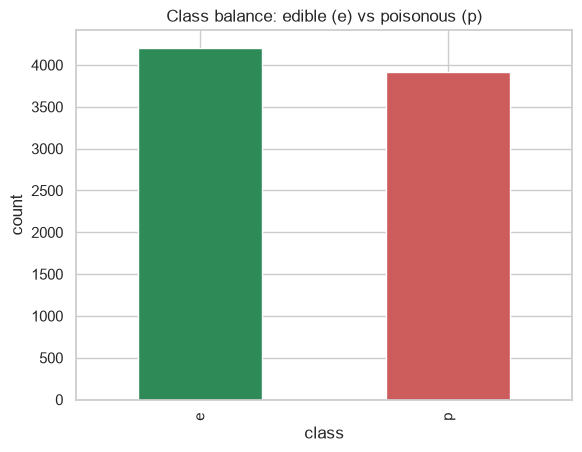

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

In [ ]:
ax = df["class"].value_counts().plot(kind="bar", color=["seagreen", "indianred"])
ax.set_title("Class balance: edible (e) vs poisonous (p)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.show()

df["class"].value_counts(normalize=True)

Since the classes are about **50 / 50**, no need to balance the data.

### 2.1 Which feature helps the most?

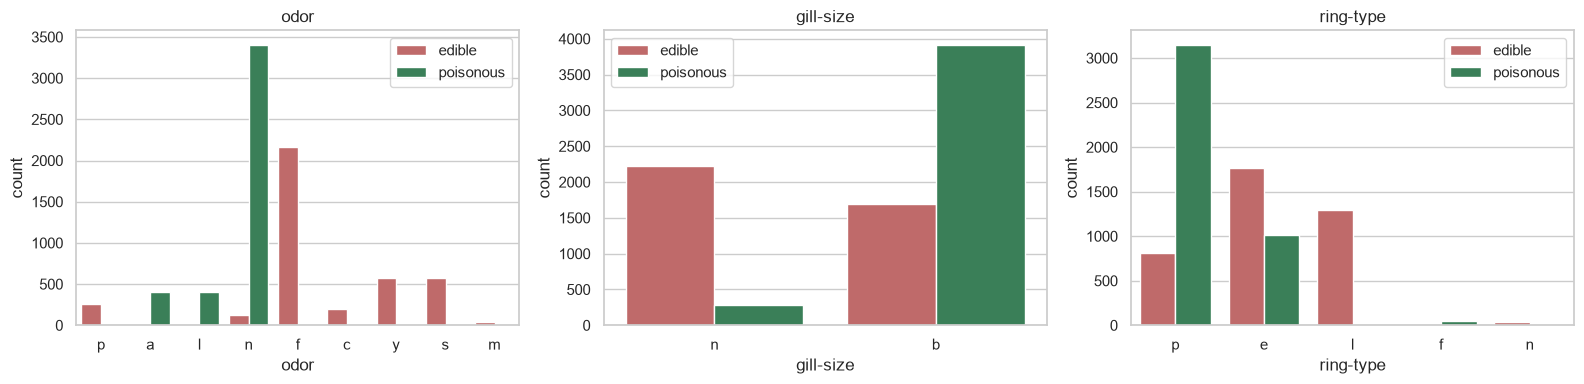

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["odor", "gill-size", "ring-type"]):
    sns.countplot(data=df, x=col, hue="class", ax=ax,
                  palette={"e": "seagreen", "p": "indianred"})
    ax.set_title(col)
    ax.legend(["edible", "poisonous"])
plt.tight_layout()
plt.show()

In [125]:
pd.crosstab(df["odor"], df["class"])

class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


Mushrooms with odor `n` (no smell) are almost all **edible**,
while smells like `f`, `p`, `c`, `y`, `s` are almost all **poisonous**. 

## 3. Turn text into numbers (one-hot encoding)

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)

Train shape: (6499, 21)  Test shape: (1625, 21)


In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train = ohe.fit_transform(X_train_raw)   # learns the categories from train set
X_test = ohe.transform(X_test_raw)         # reuses them for the test set
ohe_feature_names = ohe.get_feature_names_out(feature_cols)
print("One-hot encoded feature count:", X_train.shape[1])

One-hot encoded feature count: 116


### 3.1 A visual look: scatterplot of the two classes


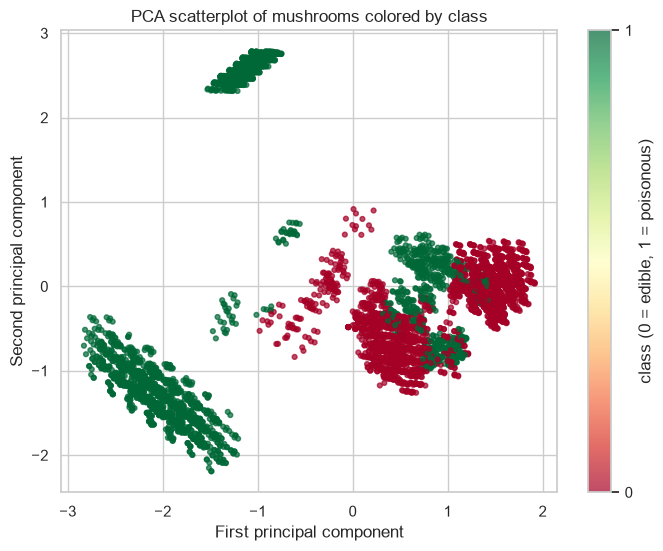

In [ ]:

from sklearn.decomposition import PCA

# PCA on the one-hot encoded training features, keeping 2 components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                 cmap="RdYlGn", s=12, alpha=0.7)
plt.colorbar(sc, ticks=[0, 1], label="class (0 = edible, 1 = poisonous)")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("PCA scatterplot of mushrooms colored by class")
plt.show()

## 4. Compare models
- **Logistic Regression** — a linear model
- **K-Nearest Neighbors (KNN)** — "look at the closest mushrooms and vote"
- **Decision Tree** — a set of if/else questions
- **Random Forest** — many decision trees voting together
- **Naive Bayes** — uses probabilities

In [ ]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "NaiveBayes": CategoricalNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in candidates.items():
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    results.append({"model": name, "cv_f1": f1_scores.mean(), "cv_accuracy": acc_scores.mean()})
    print(f"{name:20s}  F1 = {f1_scores.mean():.4f}  Accuracy = {acc_scores.mean():.4f}")

results_df = pd.DataFrame(results).sort_values("cv_f1", ascending=False).reset_index(drop=True)
results_df

LogisticRegression    F1 = 0.9994  Accuracy = 0.9994


KNN                   F1 = 0.9997  Accuracy = 0.9997


DecisionTree          F1 = 0.9997  Accuracy = 0.9997


RandomForest          F1 = 1.0000  Accuracy = 1.0000


NaiveBayes            F1 = 0.9354  Accuracy = 0.9408


,model,cv_f1,cv_accuracy
0,RandomForest,1.000000,1.000000
1,KNN,0.999681,0.999692
2,DecisionTree,0.999681,0.999692
3,LogisticRegression,0.999360,0.999385
4,NaiveBayes,0.935370,0.940762


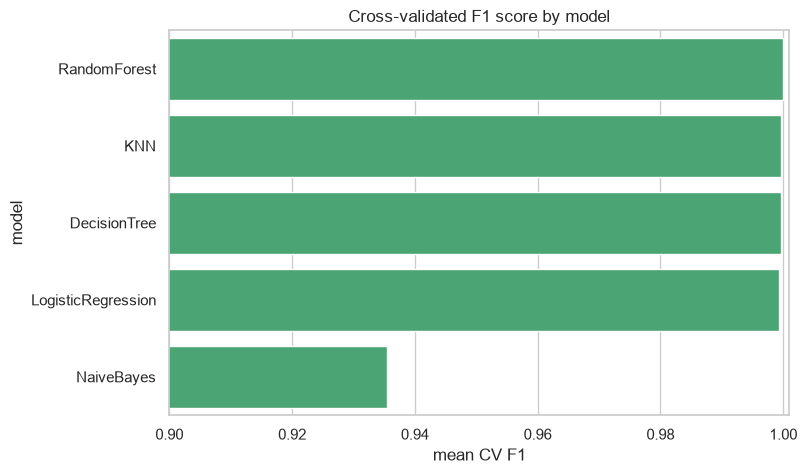

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="cv_f1", y="model", color="mediumseagreen")
plt.title("Cross-validated F1 score by model")
plt.xlabel("mean CV F1")
plt.xlim(0.9, 1.001)
plt.show()

The table above shows each model's **cross-validated F1** and **accuracy**.

## 5. Train the model on all the training data

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Random Forest trained on", X_train.shape[0], "rows.")

Random Forest trained on 6499 rows.


## 6. How well does it work?

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1       : 1.0


### 6.2 Confusion matrix

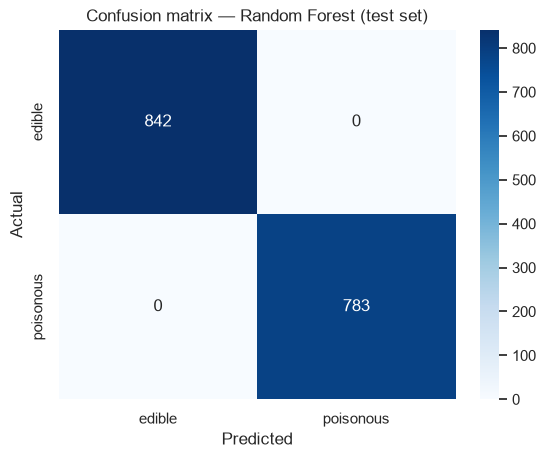

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["edible", "poisonous"],
            yticklabels=["edible", "poisonous"])
plt.title("Confusion matrix — Random Forest (test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6.3 Classification report

In [ ]:
print(classification_report(y_test, y_pred, target_names=["edible", "poisonous"]))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 6.4 Which features matter?

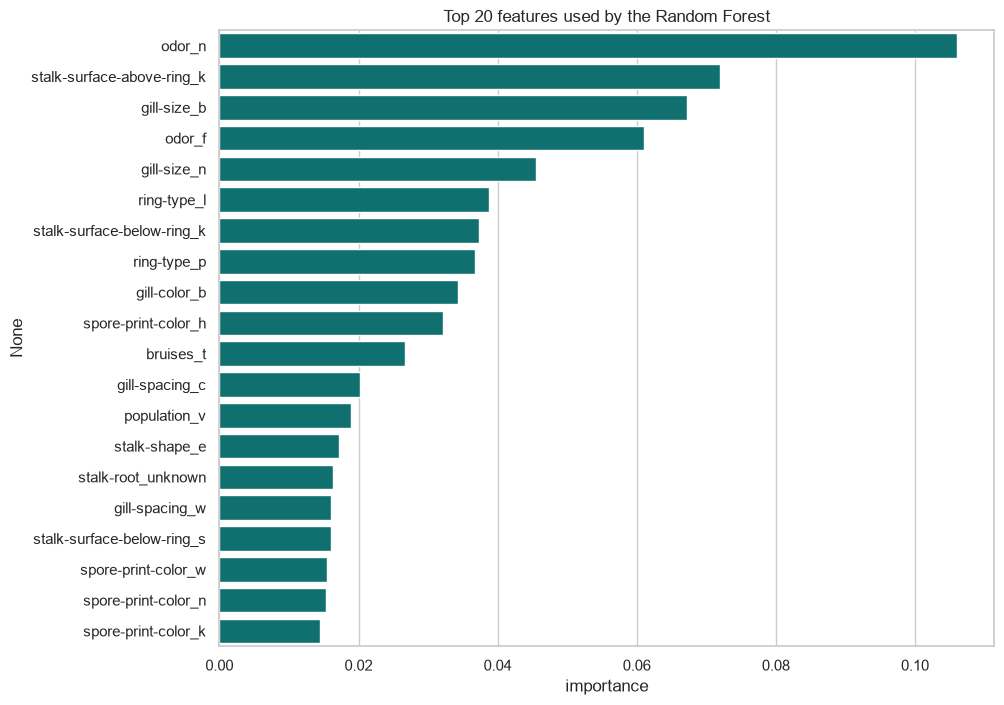

In [ ]:
importances = pd.Series(rf.feature_importances_, index=ohe_feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, color="teal")
plt.title("Top 20 features used by the Random Forest")
plt.xlabel("importance")
plt.show()